# Machine Learning Assignment 2 - Semi-Supervised Learning for Predicting Survival Time in Multiple Myeloma Patients
***
## Group Members
- Geri Aliaj - 75360
- Ben Moritz Castello - 75197
- Maria Teresa Viciosa - 75149

## Task 1 Setting the baseline

As in the previous assignment, the first step is to set a baseline. The ML task is regression, and we will fit a linear regression model as a baseline, which we can use to compare with further developments.

## Task 1.1

In [70]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, FunctionTransformer, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import time
import random
import missingno as msno


In [71]:
# Importing the Dataset
train_csv = pd.read_csv("train_data.csv")
train_csv.head(5)

,Unnamed: 0,Age,Gender,Stage,GeneticRisk,TreatmentType,ComorbidityIndex,TreatmentResponse,SurvivalTime,Censored
0,0,65.0,0,2,1.0,0,0.0,0.0,4.2,0
1,1,68.0,1,2,0.0,1,1.0,1.0,4.7,1
2,2,68.0,1,3,1.0,1,0.0,1.0,3.5,1
3,3,81.0,1,4,1.0,1,3.0,0.0,2.3,0
4,4,59.0,1,2,1.0,0,NaN,0.0,NaN,0


<Axes: >

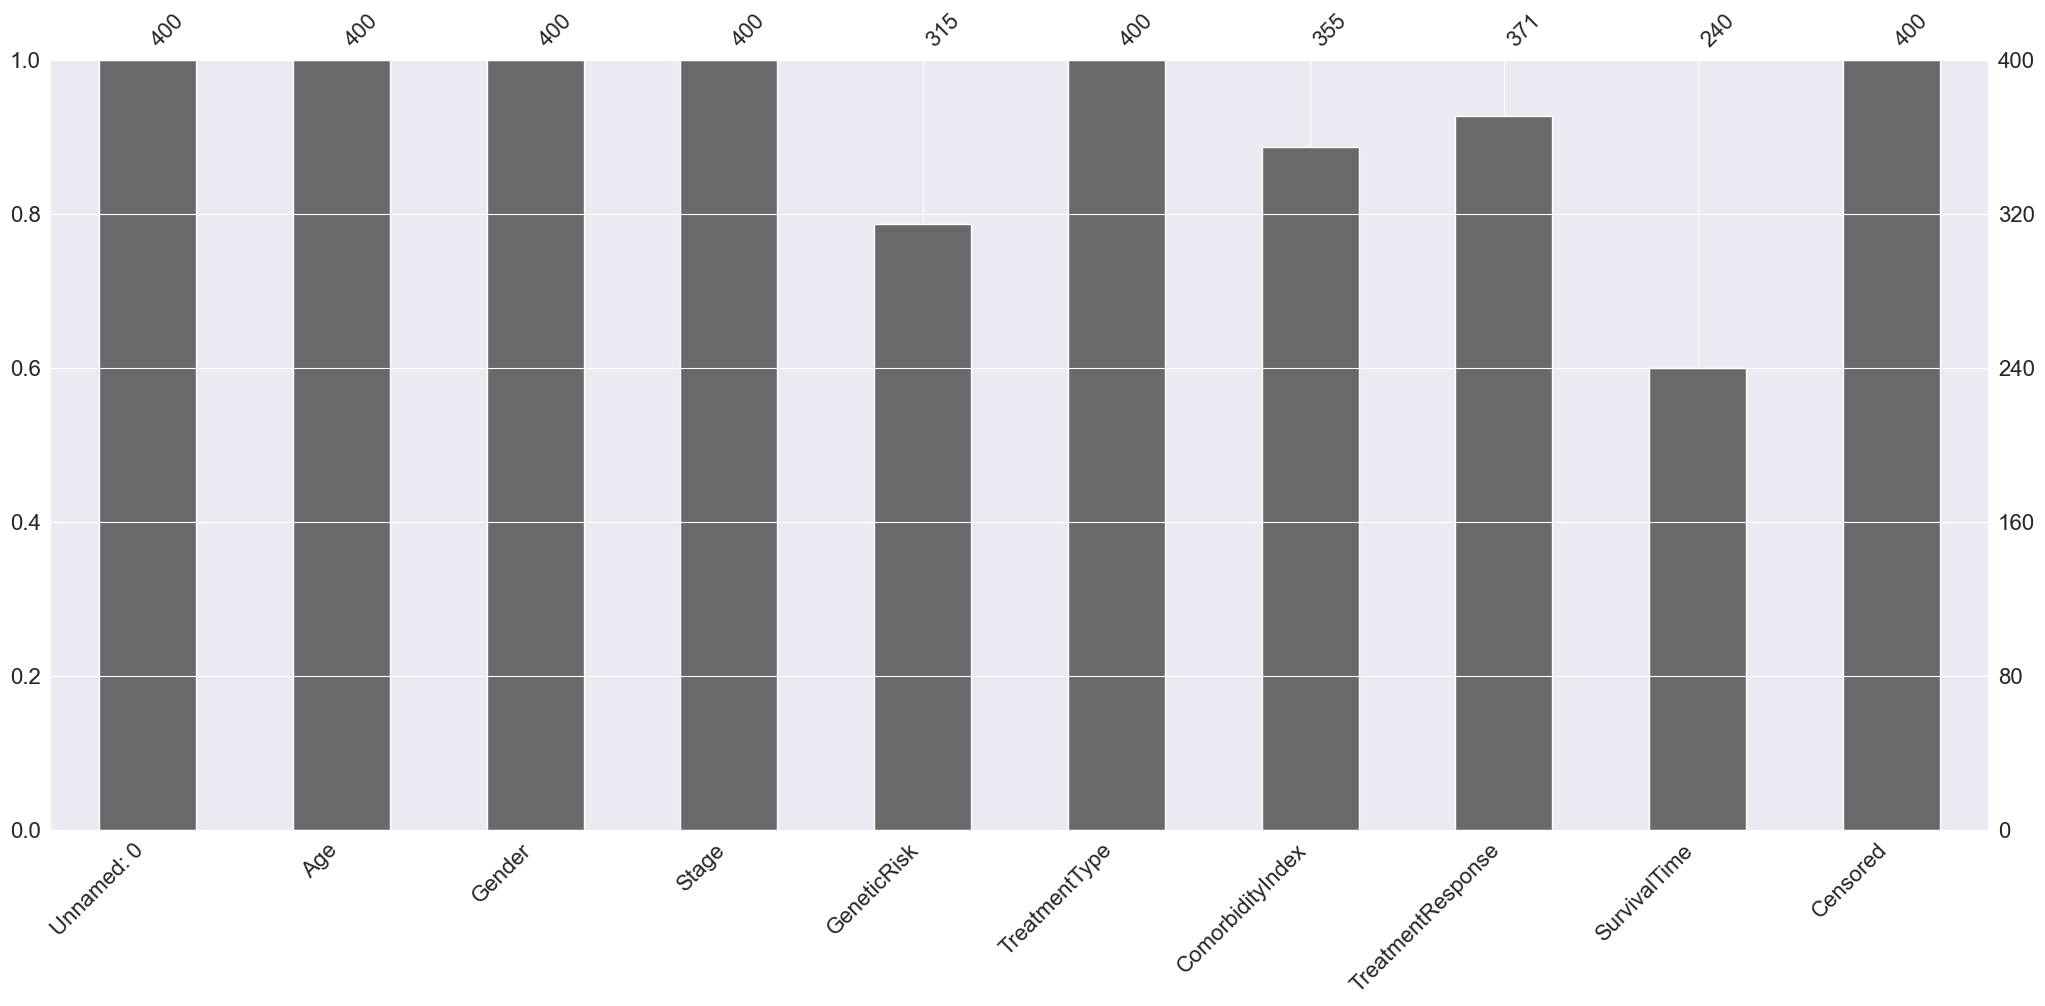

In [72]:
msno.bar(train_csv)

<Axes: >

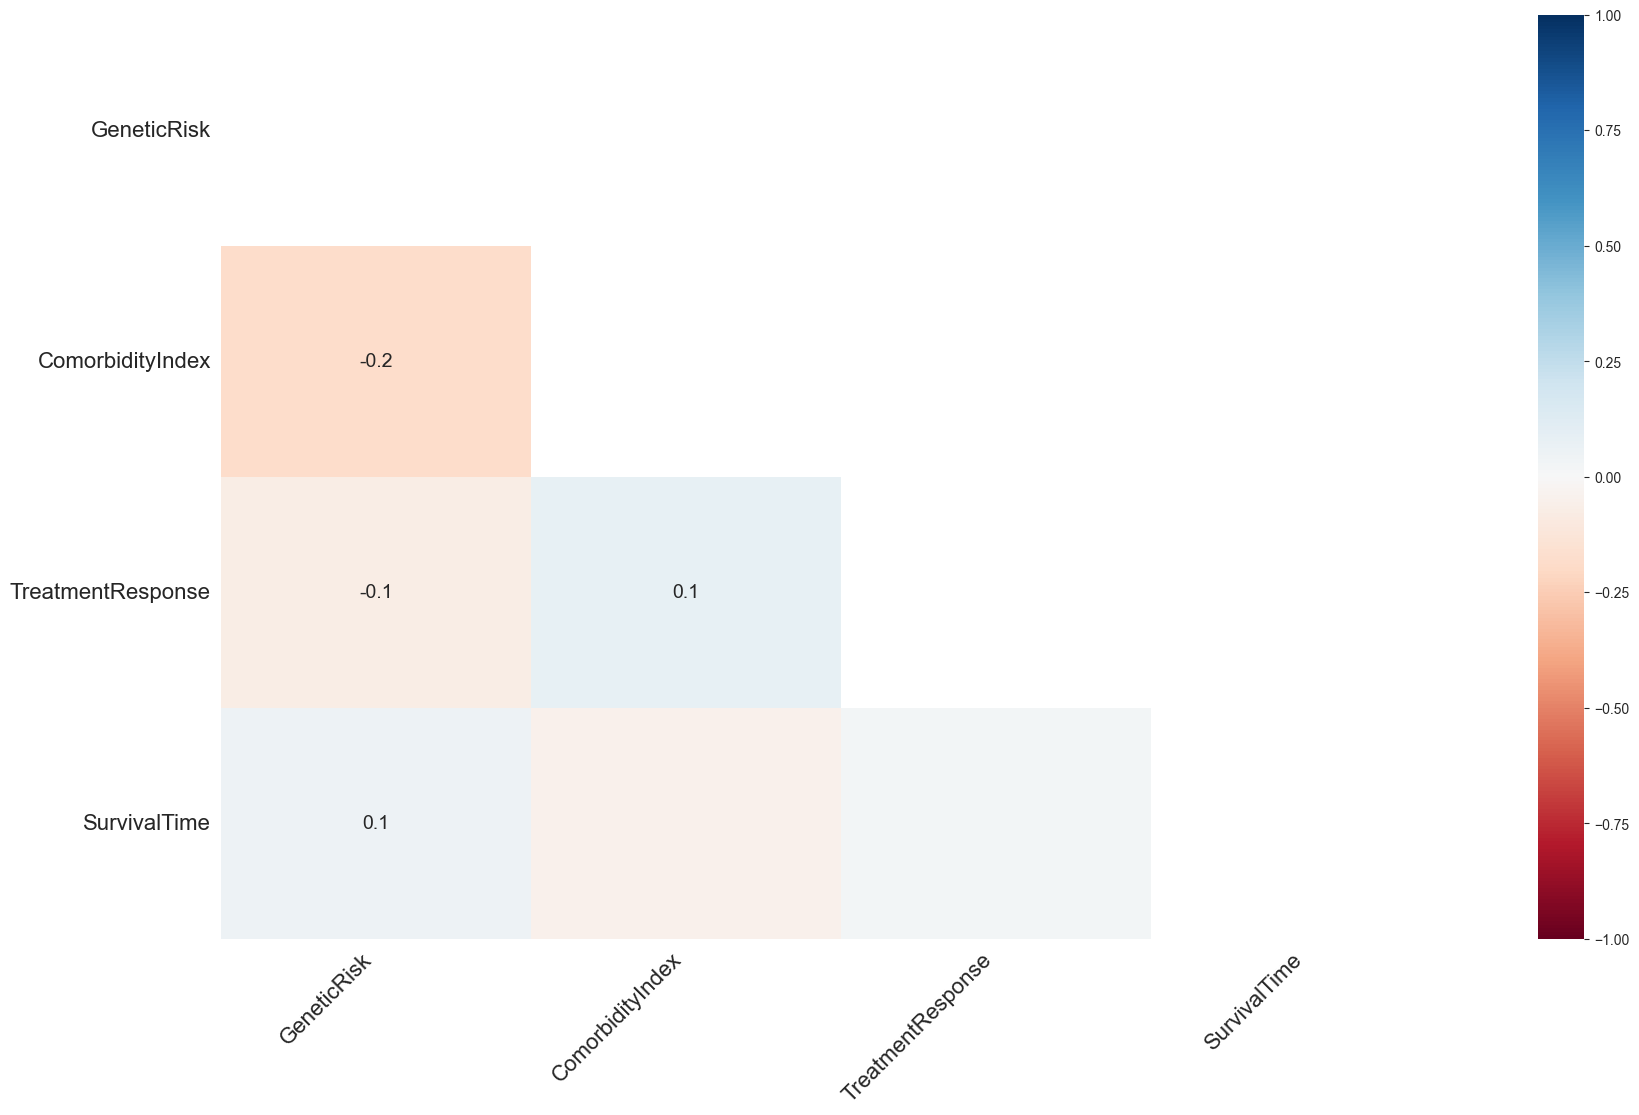

In [73]:
msno.heatmap(train_csv)

<Axes: >

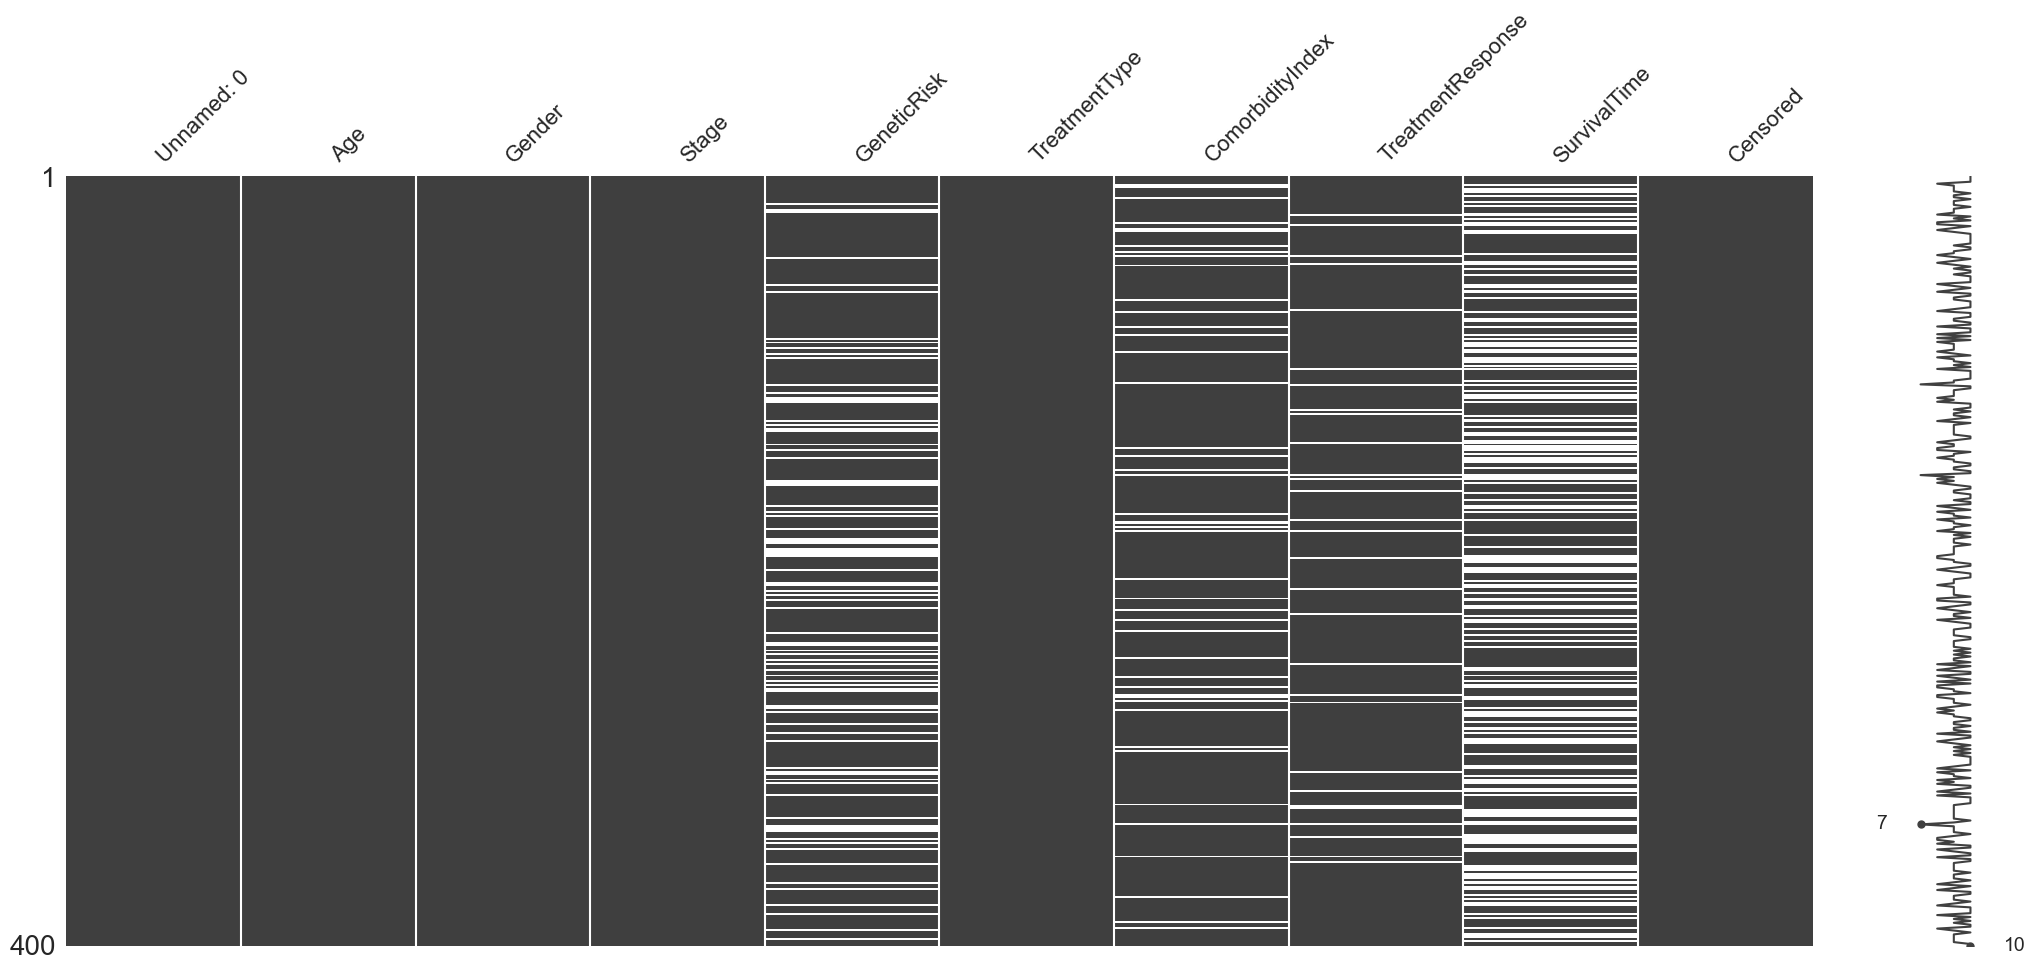

In [37]:
msno.matrix(train_csv)

<Axes: >

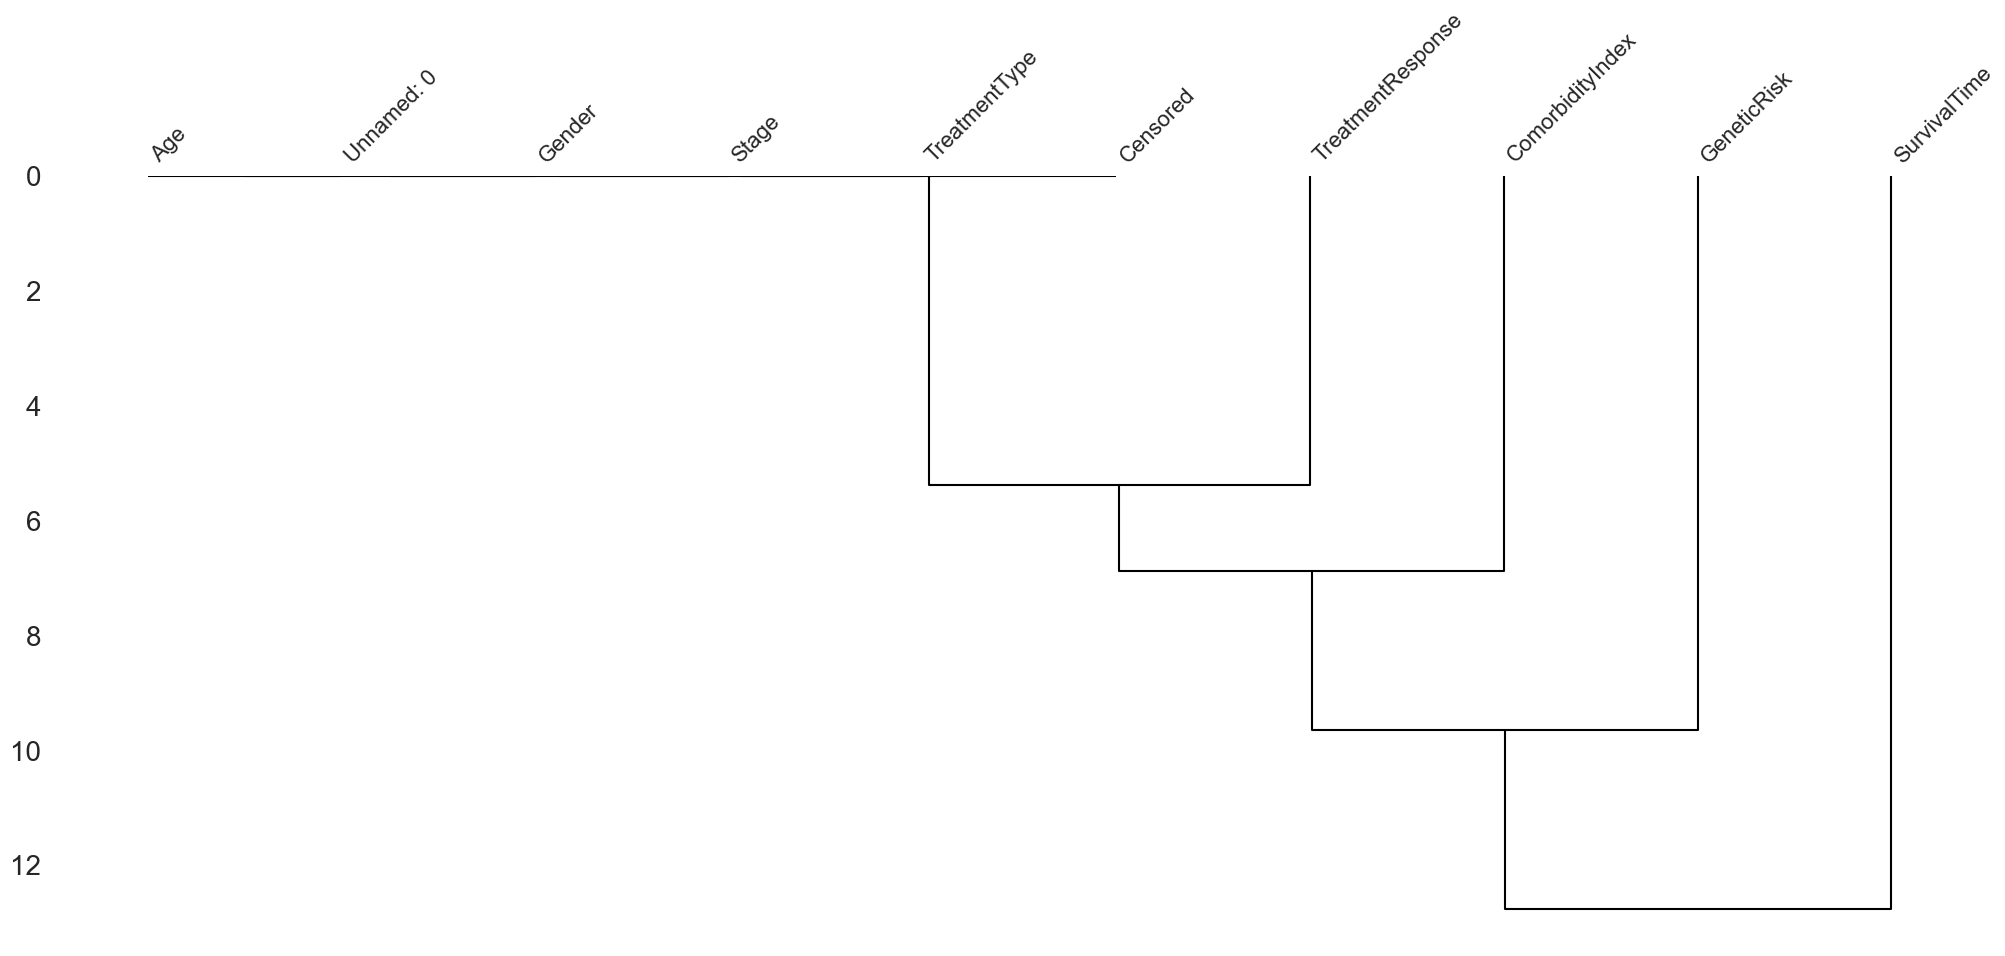

In [38]:
msno.dendrogram(train_csv)

In [39]:
cols_to_drop = [4, 6, 7]
df2 = train_csv.drop(train_csv.columns[cols_to_drop], axis=1)
df2 = df2[df2['Censored'] == 0]
df2.head(5)

,Unnamed: 0,Age,Gender,Stage,TreatmentType,SurvivalTime,Censored
0,0,65.0,0,2,0,4.2,0
3,3,81.0,1,4,1,2.3,0
4,4,59.0,1,2,0,NaN,0
5,5,47.0,1,4,1,2.6,0
6,6,59.0,1,2,0,NaN,0


In [40]:
df2.shape

(321, 7)

<Axes: >

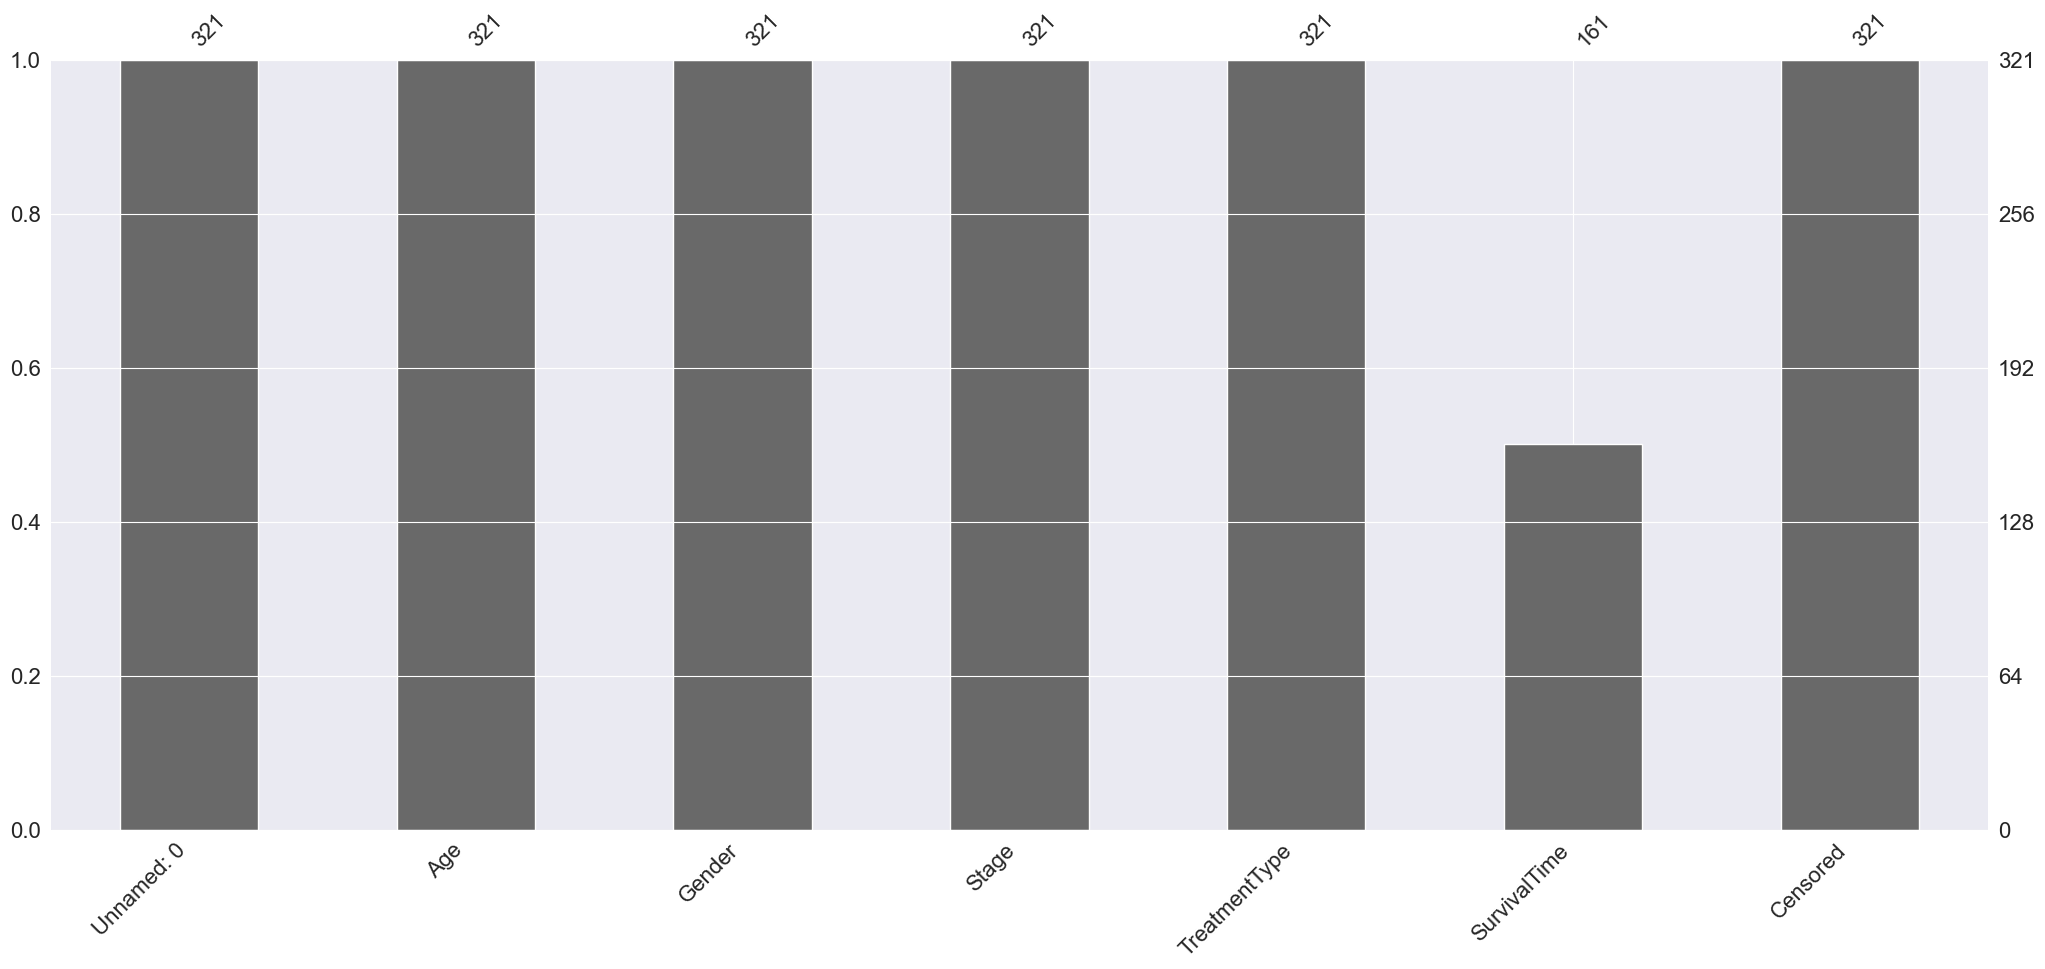

In [41]:
msno.bar(df2)

In [42]:
df2 = df2.dropna(subset=['SurvivalTime'])

<Axes: >

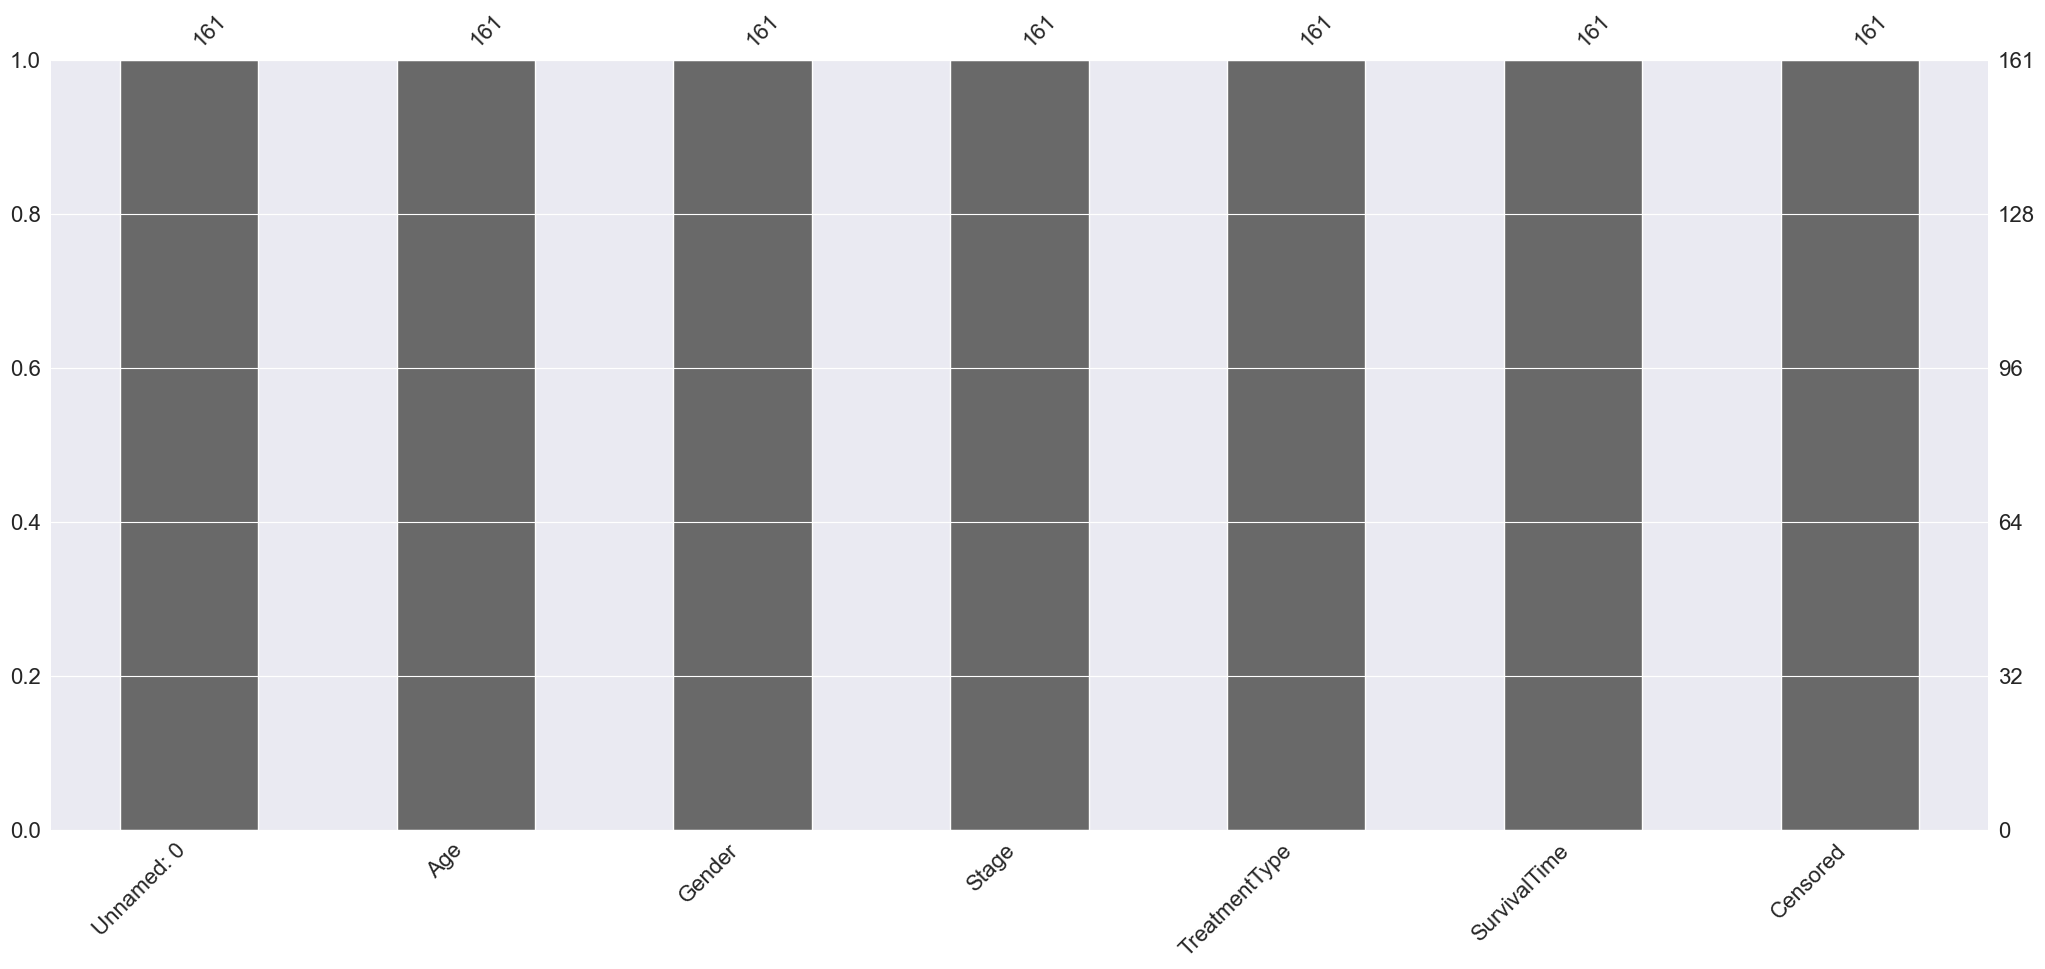

In [43]:
msno.bar(df2)

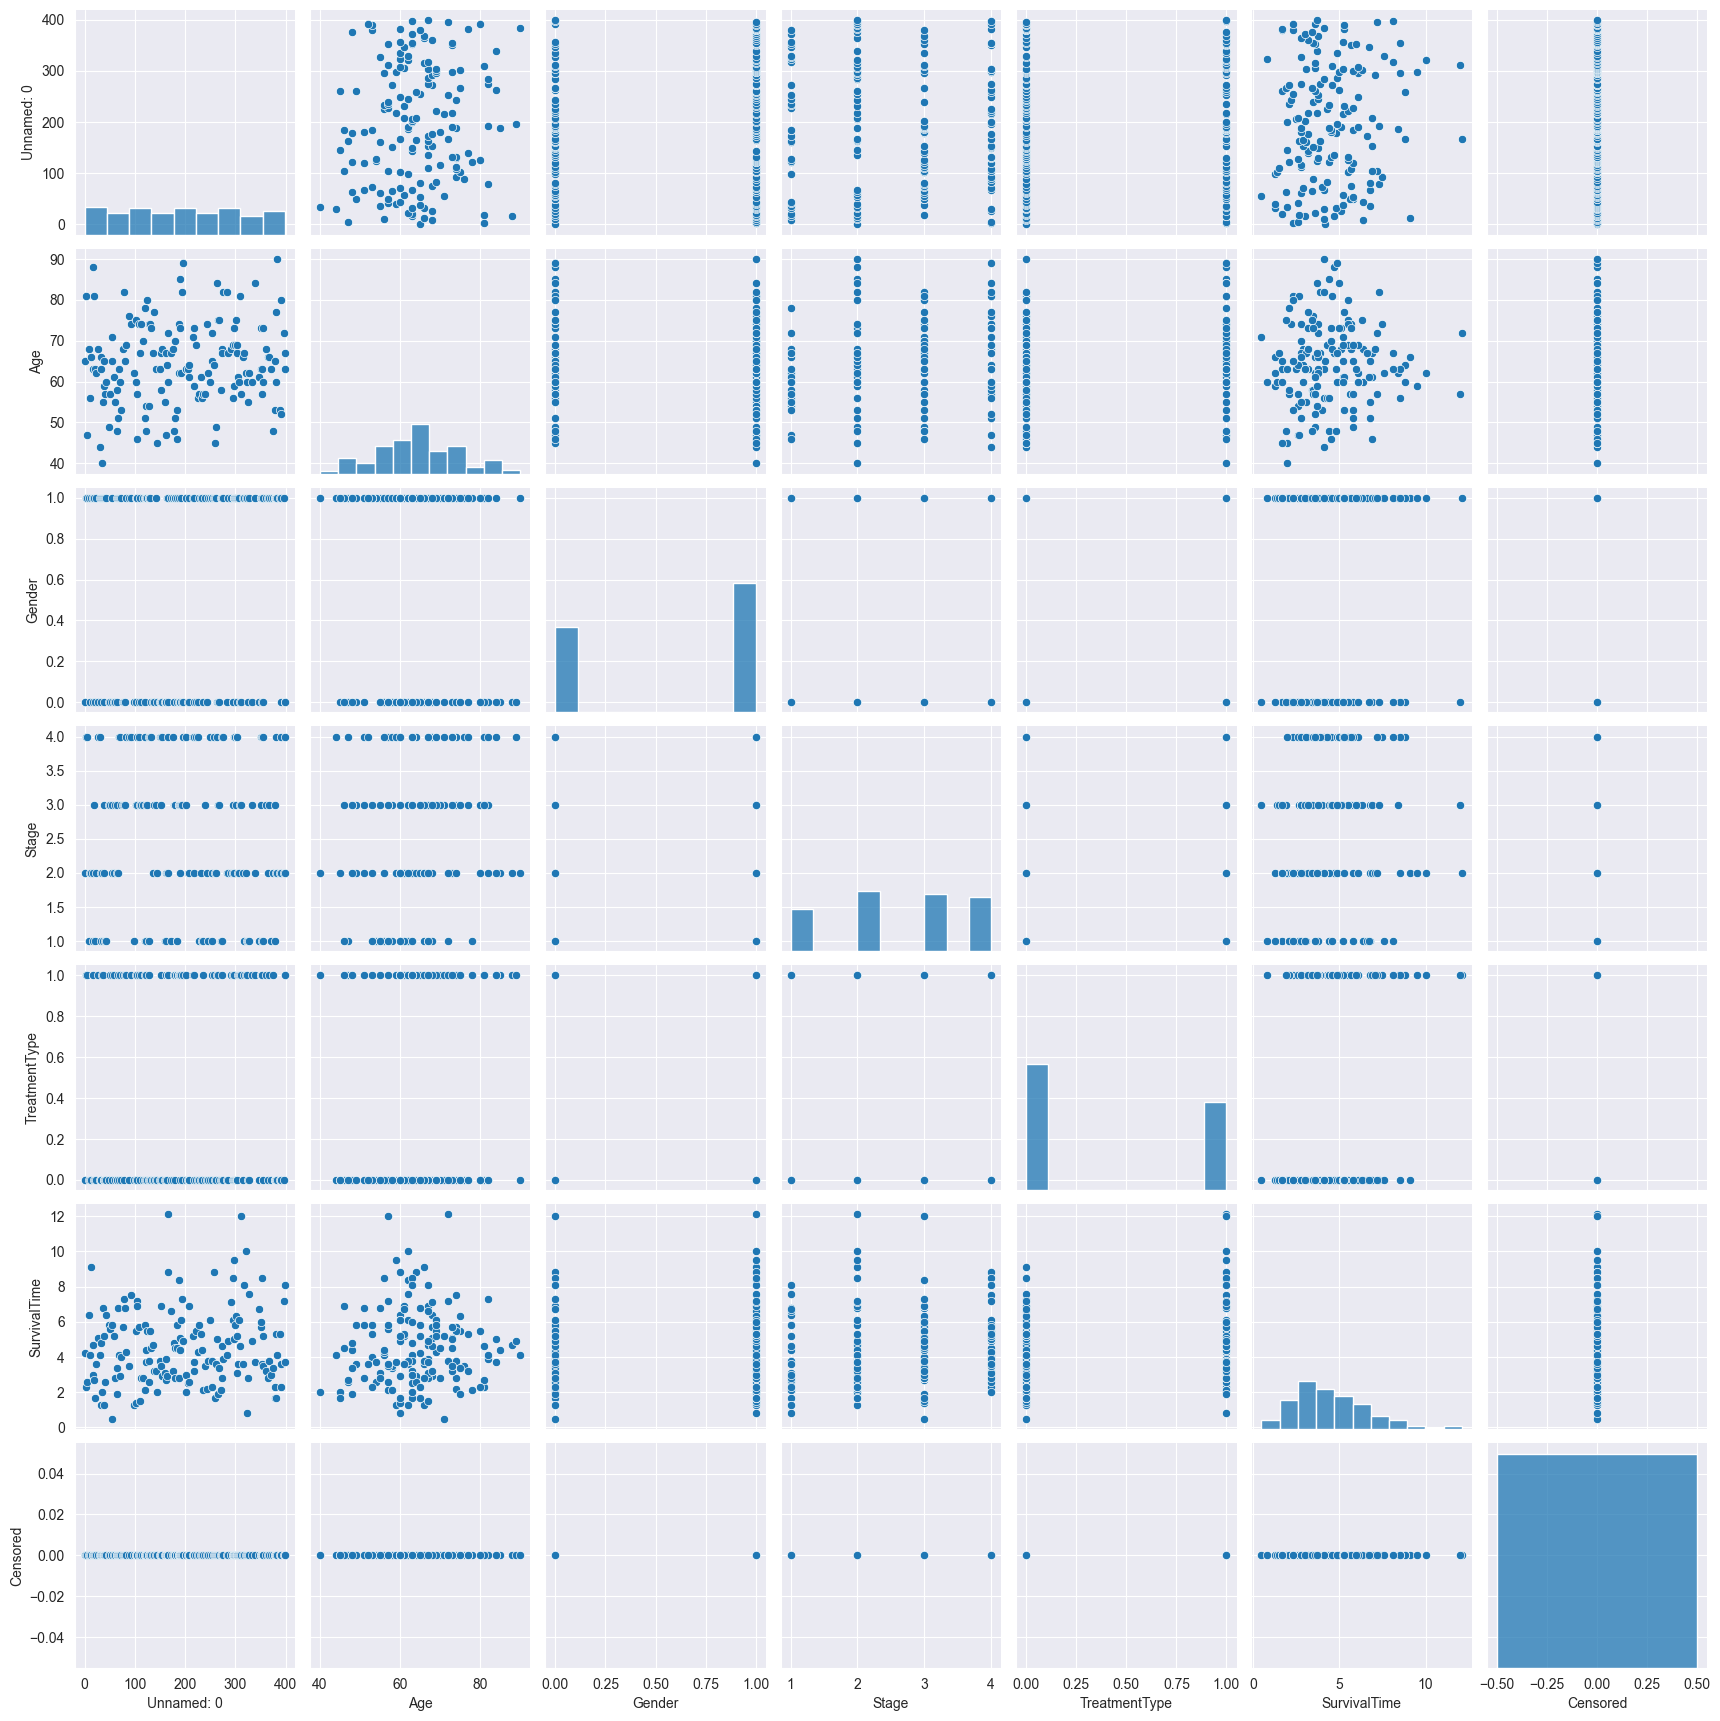

In [44]:
sns.pairplot(df2)
plt.show()

In [45]:
X = df2.drop(columns=['SurvivalTime', 'Censored'])
feature_names = X.columns
y = df2['SurvivalTime'].values
c = df2['Censored'].values

In [46]:
def plot_survival_lines(df, time_col="SurvivalTime", status_col="Censored",
                        event_value="1", sort_by_time=False, figsize=(10, 8)):
    df_plot = df.copy()
    df_plot[time_col] = pd.to_numeric(df_plot[time_col], errors="coerce")
    df_plot[status_col] = df_plot[status_col].astype(str)

    if sort_by_time:
        df_plot = df_plot.sort_values(by=time_col).reset_index(drop=True)
    else:
        df_plot = df_plot.reset_index(drop=True)

    n = len(df_plot)
    if n == 0:
        raise ValueError("Empty DataFrame.")

    plt.figure(figsize=figsize)
    plt.plot([0, df_plot[time_col].max()], [1, n], alpha=0)

    for i, row in enumerate(df_plot.itertuples(index=False), start=1):
        t = getattr(row, time_col)
        status = getattr(row, status_col)
        if pd.isna(t):
            continue
        if status == str(event_value):
            plt.hlines(i, 0, t, colors="red")
            plt.plot(t, i, marker="x", color="red", markersize=6)
        else:
            plt.hlines(i, 0, t, colors="black")

    plt.xlabel("months")
    plt.ylabel("patients")
    plt.ylim(n + 1, 0)
    plt.plot([], [], color="red", marker="x", linestyle="None",
             label=f"Event (value={event_value})")
    plt.plot([], [], color="black", label="Censored")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


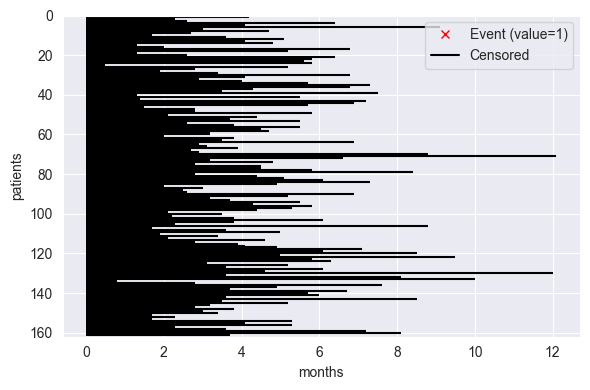

In [47]:
plot_survival_lines(df2,
                    time_col="SurvivalTime",
                    status_col="Censored",
                    event_value="1",
                    figsize=(6,4))

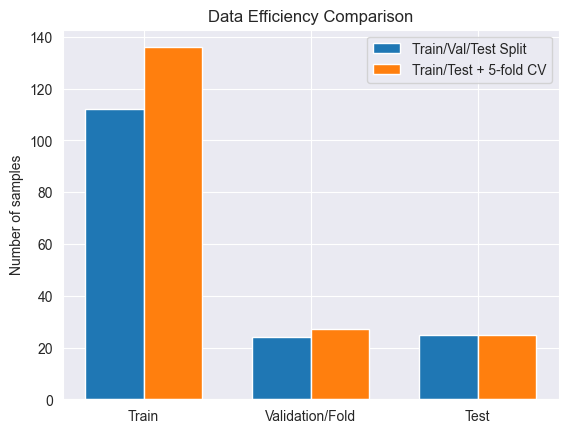

In [48]:
X_train, X_temp, y_train, y_temp, c_train, c_temp = train_test_split(
    X, y, c, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test, c_val, c_test = train_test_split(
    X_temp, y_temp, c_temp, test_size=0.5, random_state=42
)

X_train_cv, X_test_cv, y_train_cv, y_test_cv, c_train_cv, c_test_cv = train_test_split(
    X, y, c, test_size=0.15, random_state=42
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
avg_val_fold_size = np.mean([len(val_index) for _, val_index in kf.split(X_train_cv)])

train_val_test = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
train_test_cv_train = [X_train_cv.shape[0], avg_val_fold_size, X_test_cv.shape[0]]

labels = ["Train", "Validation/Fold", "Test"]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width / 2, train_val_test, width, label="Train/Val/Test Split")
ax.bar(x + width / 2, train_test_cv_train, width, label="Train/Test + 5-fold CV")

ax.set_ylabel("Number of samples")
ax.set_title("Data Efficiency Comparison")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()

Summarizing:
Train/Val/Test (70/15/15)
Only 70% of the data participates in the final training.

Train/Test + 5-fold CV (85/15)
85% of the data is used for training in every fold.
Each sample is used for training 4 times (in 5-fold CV).

Therefore, in terms of the total number of “training uses per sample”:

Train/Val/Test:
0.70 × 1 = 0.70 training units

5-fold CV:
0.85 × 4 = 3.40 training units

→ This clearly shows that cross-validation extracts much more informative use from the data.

NOTE: the dataset is the same in both methods; the difference lies in how many times each method uses the training samples.


In [49]:
def error_metric(y, y_hat, c):
    import numpy as np
    err = y-y_hat
    err = (1-c)*err**2 + c*np.maximum(0,err)**2
    return np.sum(err)/err.shape[0]

## Task 1.2 Learn the Baseline Model

In [50]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])

In [53]:
kaggle_test = pd.read_csv("test_data.csv")

kaggle_test = kaggle_test.loc[:, ~kaggle_test.columns.str.contains("Unnamed")]

train_features = ['Unnamed: 0', 'Age', 'Gender', 'Stage', 'TreatmentType']

X_kaggle_df = pd.DataFrame(columns=train_features)

for col in ['Age', 'Gender', 'Stage', 'TreatmentType']:
    X_kaggle_df[col] = kaggle_test[col]

X_kaggle_df['Unnamed: 0'] = 0

X_kaggle = X_kaggle_df.to_numpy()

print("Kaggle final shape:", X_kaggle.shape)
print("Train final shape:", X_train.shape)

pred_kaggle = pipeline.predict(X_kaggle)

submission = pd.DataFrame({
    "SurvivalTime": pred_kaggle
})

submission_file = "baseline-submission-01.csv"
submission.to_csv(submission_file, index=False)

print(f"Submission file saved as {submission_file}")
submission.head()

Kaggle final shape: (100, 5)
Train final shape: (112, 5)


NotFittedError: Pipeline is not fitted yet.

Kaggle final shape: (100, 5)
Train final shape: (112, 5)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: X has 7 features, but StandardScaler is expecting 5 features as input.

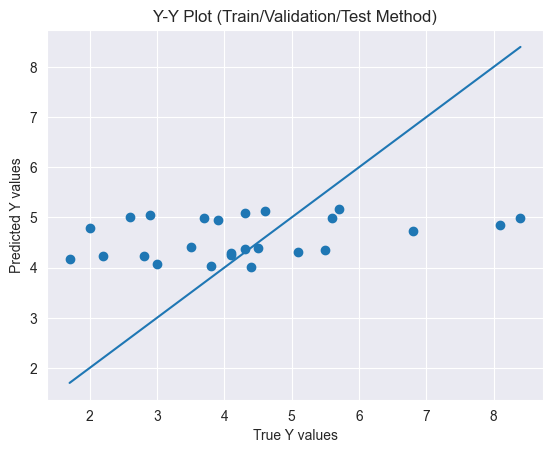

In [54]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("True Y values")
plt.ylabel("Predicted Y values")
plt.title("Y-Y Plot (Train/Validation/Test Method)")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

In [55]:
fold_metrics = []
fold_predictions = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_cv), start=1):
    X_tr = X_train_cv.iloc[train_idx]
    X_val = X_train_cv.iloc[val_idx]

    y_tr = y_train_cv[train_idx]
    y_val = y_train_cv[val_idx]

    c_tr = c_train_cv[train_idx]
    c_val = c_train_cv[val_idx]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("linreg", LinearRegression())
    ])

    pipeline.fit(X_tr, y_tr)
    y_pred_val = pipeline.predict(X_val)

    mse = mean_squared_error(y_val, y_pred_val)
    r2 = r2_score(y_val, y_pred_val)
    mae = mean_absolute_error(y_val, y_pred_val)

    fold_metrics.append((mse, r2, mae))

mse_vals = [m for m, _, _ in fold_metrics]
r2_vals = [r for _, r, _ in fold_metrics]
mae_vals = [a for _, _, a in fold_metrics]

print("=== 5-Fold CV Method 2 ===")
print(f"Validation: MSE={np.mean(mse_vals):.4f} ± {np.std(mse_vals):.4f}, "
      f"R2={np.mean(r2_vals):.4f} ± {np.std(r2_vals):.4f}, "
      f"MAE={np.mean(mae_vals):.4f} ± {np.std(mae_vals):.4f}")

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])

final_pipeline.fit(X_train_cv, y_train_cv)
y_pred_test_cv = final_pipeline.predict(X_test_cv)

print(f"Test: MSE={mean_squared_error(y_test_cv, y_pred_test_cv):.4f}, "
      f"R2={r2_score(y_test_cv, y_pred_test_cv):.4f}, "
      f"MAE={mean_absolute_error(y_test_cv, y_pred_test_cv):.4f}")

=== 5-Fold CV Method 2 ===
Validation: MSE=4.5466 ± 0.8005, R2=-0.0924 ± 0.1734, MAE=1.7092 ± 0.1914
Test: MSE=3.5050, R2=0.1570, MAE=1.5170


The evolution in MSE (or R2 or MAE) doesn't show a tendency: this is due to differences in the files and also to the fact that
the train is done in each file without any "memory" of what was done in the previous one(s) - NO LEAKAGE = each fold is an independent experience

Submit the predictions of the baseline model to Kaggle with the name baseline-submission-xx.csv where xx is a natural number. The submission used for grading is the one with the larger value. ---> We have to submit results from this CV-5 fold model beacuse is that presenting highest score values as asked.

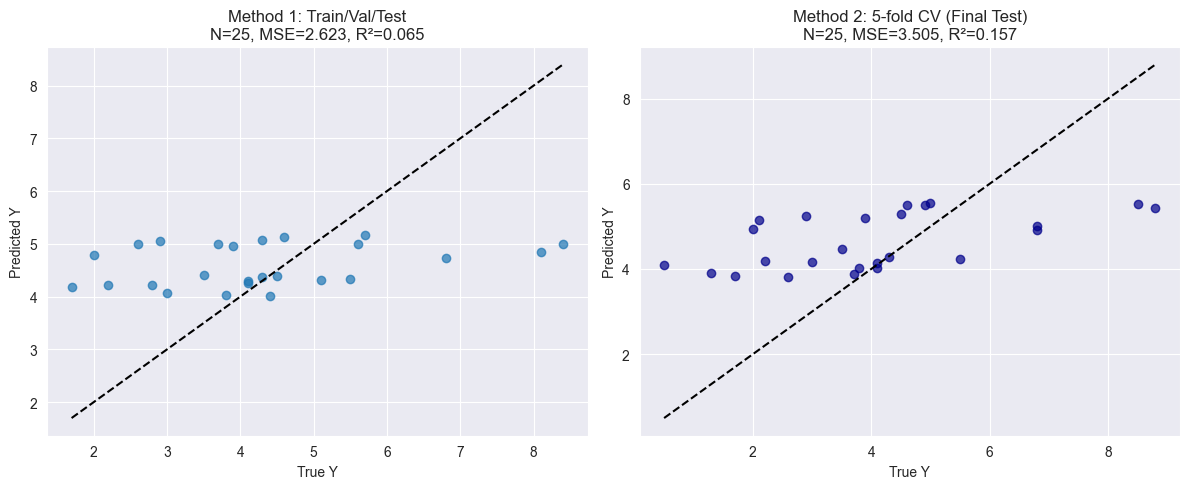

In [56]:
mse_1 = mean_squared_error(y_test, y_pred)
r2_1 = r2_score(y_test, y_pred)
n_1 = len(y_test)

mse_2 = mean_squared_error(y_test_cv, y_pred_test_cv)
r2_2 = r2_score(y_test_cv, y_pred_test_cv)
n_2 = len(y_test_cv)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred, alpha=0.7, color="C0")
axes[0].set_xlabel("True Y")
axes[0].set_ylabel("Predicted Y")
axes[0].set_title(f"Method 1: Train/Val/Test\nN={n_1}, MSE={mse_1:.3f}, R²={r2_1:.3f}")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black")

axes[1].scatter(y_test_cv, y_pred_test_cv, alpha=0.7, color="darkblue")
axes[1].set_xlabel("True Y")
axes[1].set_ylabel("Predicted Y")
axes[1].set_title(f"Method 2: 5-fold CV (Final Test)\nN={n_2}, MSE={mse_2:.3f}, R²={r2_2:.3f}")

min_val_cv = min(y_test_cv.min(), y_pred_test_cv.min())
max_val_cv = max(y_test_cv.max(), y_pred_test_cv.max())
axes[1].plot([min_val_cv, max_val_cv], [min_val_cv, max_val_cv], linestyle="--", color="black")

plt.tight_layout()
plt.show()

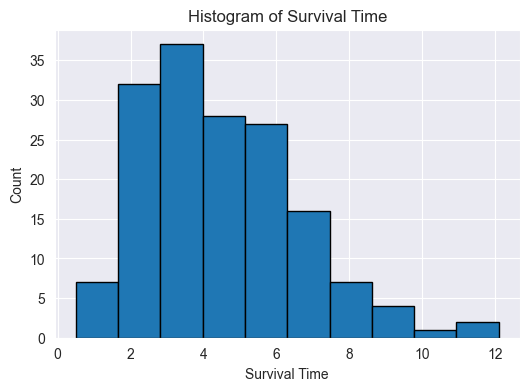

In [57]:
plt.figure(figsize=(6,4))
plt.hist(df2["SurvivalTime"], bins=10, edgecolor='black')
plt.xlabel("Survival Time")
plt.ylabel("Count")
plt.title("Histogram of Survival Time")
plt.grid(True)
plt.show()

The survival time in df2 follows an asymetrical distribution, then we can try to transform this variable by log and try other model
 ... to test

## Task 2 Nonlinear models

## Task 2.1 Development with polynomial regression

=== Polynomial Degree 2 ===
Validation: MSE=3.3847, R2=0.0659, MAE=1.2499
Test:       MSE=2.6253, R2=0.0639, MAE=1.2649

=== Polynomial Degree 3 ===
Validation: MSE=1.8390, R2=0.4925, MAE=1.0136
Test:       MSE=4.9350, R2=-0.7597, MAE=1.7856



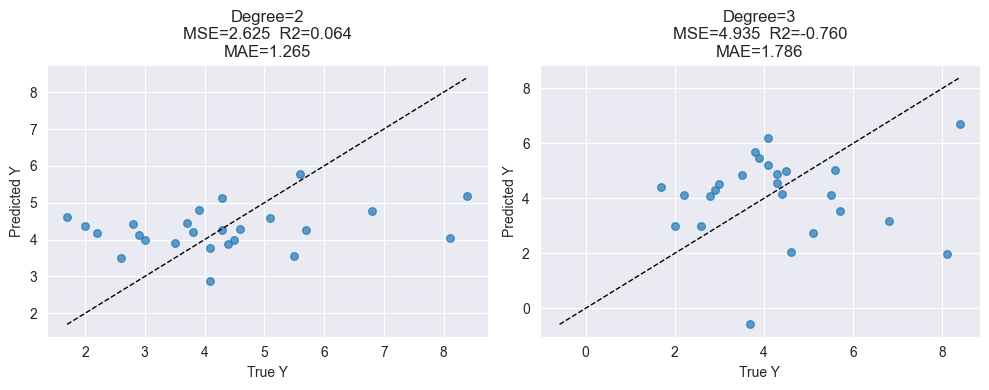

In [58]:
degrees = [2, 3]

fig, axes = plt.subplots(1, len(degrees), figsize=(5 * len(degrees), 4))

for i, deg in enumerate(degrees):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("linreg", LinearRegression())
    ])

    model.fit(X_train, y_train)

    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)

    mse_val = mean_squared_error(y_val, y_pred_val)
    r2_val = r2_score(y_val, y_pred_val)
    mae_val = mean_absolute_error(y_val, y_pred_val)

    mse_test = mean_squared_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    print(f"=== Polynomial Degree {deg} ===")
    print(f"Validation: MSE={mse_val:.4f}, R2={r2_val:.4f}, MAE={mae_val:.4f}")
    print(f"Test:       MSE={mse_test:.4f}, R2={r2_test:.4f}, MAE={mae_test:.4f}\n")

    ax = axes[i]
    ax.scatter(y_test, y_pred_test, alpha=0.7, s=30)
    mn = min(np.min(y_test), np.min(y_pred_test))
    mx = max(np.max(y_test), np.max(y_pred_test))
    ax.plot([mn, mx], [mn, mx], linestyle="--", color="black", linewidth=1)
    ax.set_title(f"Degree={deg}\nMSE={mse_test:.3f}  R2={r2_test:.3f}\nMAE={mae_test:.3f}")
    ax.set_xlabel("True Y")
    ax.set_ylabel("Predicted Y")
    ax.grid(True)

plt.tight_layout()
plt.show()

=== Polynomial Degree 2 (5-fold CV) ===
MSE:  5.3484 ± 1.0202
R2:   -0.2906 ± 0.2767
MAE:  1.8828 ± 0.2405
cMSE: 5.3484 ± 1.0202

=== Polynomial Degree 3 (5-fold CV) ===
MSE:  8.3761 ± 2.4168
R2:   -1.0959 ± 0.8789
MAE:  2.2676 ± 0.4032
cMSE: 8.3761 ± 2.4168

Final Test — Degree 2: MSE=3.6868, R2=0.1133, MAE=1.6652, cMSE=3.6868
Final Test — Degree 3: MSE=6.8074, R2=-0.6373, MAE=2.0887, cMSE=6.8074


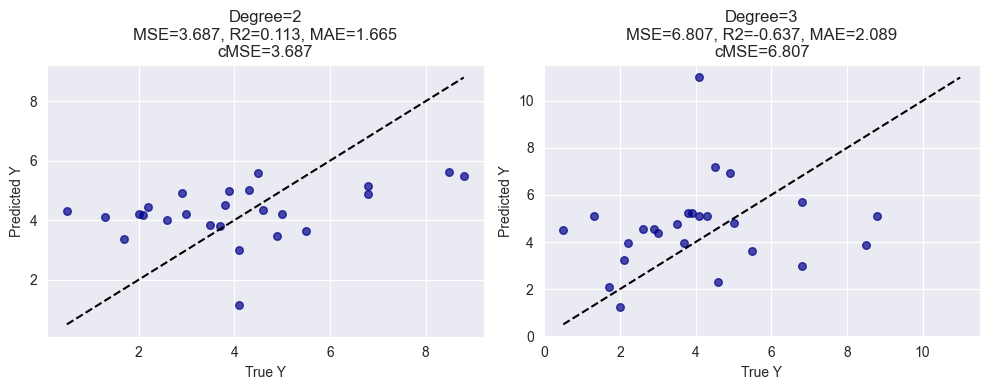

In [59]:
degrees = [2, 3]
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for deg in degrees:
    fold_metrics = []

    for train_idx, val_idx in kf.split(X_train_cv):
        X_tr = X_train_cv.iloc[train_idx]
        X_val = X_train_cv.iloc[val_idx]

        y_tr = y_train_cv[train_idx]
        y_val = y_train_cv[val_idx]

        c_tr = c_train_cv[train_idx]
        c_val = c_train_cv[val_idx]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
            ("linreg", LinearRegression())
        ])

        model.fit(X_tr, y_tr)
        y_pred_val = model.predict(X_val)

        mse = mean_squared_error(y_val, y_pred_val)
        r2 = r2_score(y_val, y_pred_val)
        mae = mean_absolute_error(y_val, y_pred_val)
        cust = error_metric(y_val, y_pred_val, c_val)

        fold_metrics.append((mse, r2, mae, cust))

    fold_metrics = np.array(fold_metrics)
    cv_results[deg] = fold_metrics

    print(f"=== Polynomial Degree {deg} (5-fold CV) ===")
    print(f"MSE:  {fold_metrics[:, 0].mean():.4f} ± {fold_metrics[:, 0].std():.4f}")
    print(f"R2:   {fold_metrics[:, 1].mean():.4f} ± {fold_metrics[:, 1].std():.4f}")
    print(f"MAE:  {fold_metrics[:, 2].mean():.4f} ± {fold_metrics[:, 2].std():.4f}")
    print(f"cMSE: {fold_metrics[:, 3].mean():.4f} ± {fold_metrics[:, 3].std():.4f}\n")

fig, axes = plt.subplots(1, len(degrees), figsize=(5 * len(degrees), 4))

for i, deg in enumerate(degrees):
    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("linreg", LinearRegression())
    ])

    final_model.fit(X_train_cv, y_train_cv)
    y_pred_test = final_model.predict(X_test_cv)

    mse_test = mean_squared_error(y_test_cv, y_pred_test)
    r2_test = r2_score(y_test_cv, y_pred_test)
    mae_test = mean_absolute_error(y_test_cv, y_pred_test)
    custom_test = error_metric(y_test_cv, y_pred_test, c_test_cv)

    print(f"Final Test — Degree {deg}: "
          f"MSE={mse_test:.4f}, R2={r2_test:.4f}, MAE={mae_test:.4f}, cMSE={custom_test:.4f}")

    ax = axes[i]
    ax.scatter(y_test_cv, y_pred_test, alpha=0.7, s=30, color="darkblue")

    mn = min(y_test_cv.min(), y_pred_test.min())
    mx = max(y_test_cv.max(), y_pred_test.max())
    ax.plot([mn, mx], [mn, mx], linestyle="--", color="black")

    ax.set_xlabel("True Y")
    ax.set_ylabel("Predicted Y")
    ax.set_title(
        f"Degree={deg}\nMSE={mse_test:.3f}, R2={r2_test:.3f}, MAE={mae_test:.3f}\ncMSE={custom_test:.3f}"
    )

plt.tight_layout()
plt.show()

## Kaggle Submission "Nonlinear-submission-01.csv"

In [60]:
test_df = pd.read_csv("test_data.csv")

model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linreg", LinearRegression())
])
model.fit(X_train_cv, y_train_cv)

X_kaggle = test_df[X_train_cv.columns]
y_pred_test = model.predict(X_kaggle)

submission = pd.DataFrame({
    "SurvivalTime": y_pred_test
})

submission.to_csv("Nonlinear-submission-01.csv", index=False)
print("Saved: Nonlinear-submission-01.csv")

KeyError: "['Unnamed: 0'] not in index"

## Task 2.1 Development with kNN

=== k = 2 ===
Validation: MSE=1.5773, R2=0.5647, MAE=1.0056, CustomErr(c=0.5)=1.3905
Test:       MSE=3.9661, R2=-0.4142, MAE=1.6580, CustomErr(c=0.5)=3.1935

=== k = 3 ===
Validation: MSE=1.9156, R2=0.4714, MAE=1.1346, CustomErr(c=0.5)=1.6093
Test:       MSE=3.9119, R2=-0.3949, MAE=1.5853, CustomErr(c=0.5)=2.9996

=== k = 4 ===
Validation: MSE=2.6362, R2=0.2725, MAE=1.1926, CustomErr(c=0.5)=2.2870
Test:       MSE=3.4462, R2=-0.2289, MAE=1.5330, CustomErr(c=0.5)=2.4968



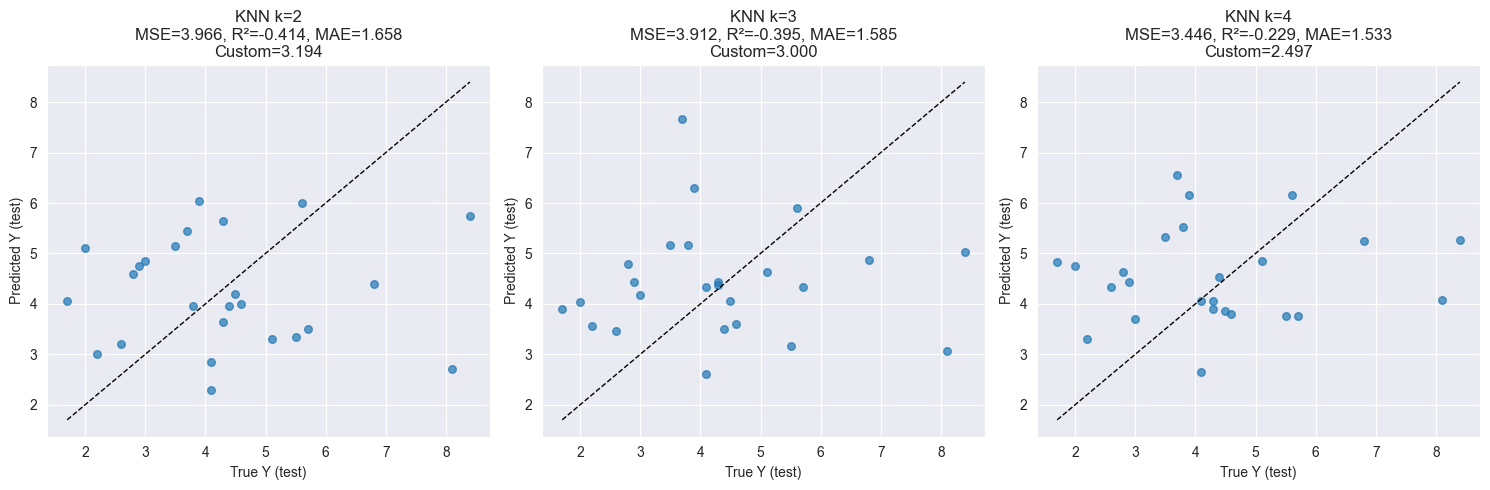

In [61]:
k_values = [2, 3, 4]
c = 0.5

fig, axes = plt.subplots(1, len(k_values), figsize=(5 * len(k_values), 5))

for i, k in enumerate(k_values):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])

    model.fit(X_train, y_train)

    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)

    mse_val = mean_squared_error(y_val, y_pred_val)
    r2_val = r2_score(y_val, y_pred_val)
    mae_val = mean_absolute_error(y_val, y_pred_val)
    custom_val = error_metric(y_val, y_pred_val, c)

    mse_test = mean_squared_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    custom_test = error_metric(y_test, y_pred_test, c)

    print(f"=== k = {k} ===")
    print(f"Validation: MSE={mse_val:.4f}, R2={r2_val:.4f}, MAE={mae_val:.4f}, CustomErr(c={c})={custom_val:.4f}")
    print(f"Test:       MSE={mse_test:.4f}, R2={r2_test:.4f}, MAE={mae_test:.4f}, CustomErr(c={c})={custom_test:.4f}\n")

    ax = axes[i]
    ax.scatter(y_test, y_pred_test, alpha=0.7, s=30)
    mn = min(np.min(y_test), np.min(y_pred_test))
    mx = max(np.max(y_test), np.max(y_pred_test))
    ax.plot([mn, mx], [mn, mx], linestyle="--", color="black", linewidth=1)
    ax.set_xlabel("True Y (test)")
    ax.set_ylabel("Predicted Y (test)")
    ax.set_title(f"KNN k={k}\nMSE={mse_test:.3f}, R²={r2_test:.3f}, MAE={mae_test:.3f}\nCustom={custom_test:.3f}")
    ax.grid(True)

plt.tight_layout()
plt.show()


=== KNN k=2 (5-fold CV) ===
MSE:    5.9458 ± 1.0706
R²:     -0.4361 ± 0.2972
MAE:    1.9480 ± 0.2553
Custom: 4.5068 ± 0.9292

=== KNN k=3 (5-fold CV) ===
MSE:    5.5331 ± 1.0350
R²:     -0.3535 ± 0.3739
MAE:    1.8654 ± 0.2629
Custom: 4.1089 ± 0.5292

=== KNN k=4 (5-fold CV) ===
MSE:    5.1768 ± 1.2330
R²:     -0.2567 ± 0.3747
MAE:    1.8193 ± 0.2535
Custom: 3.8737 ± 0.7354

=== Final Test Metrics (k=2) ===
MSE:    5.1201
R²:     -0.2315
MAE:    1.9540
Custom: 3.8581

=== Final Test Metrics (k=3) ===
MSE:    5.7987
R²:     -0.3947
MAE:    2.0307
Custom: 3.9231

=== Final Test Metrics (k=4) ===
MSE:    5.1628
R²:     -0.2417
MAE:    1.9150
Custom: 3.4054


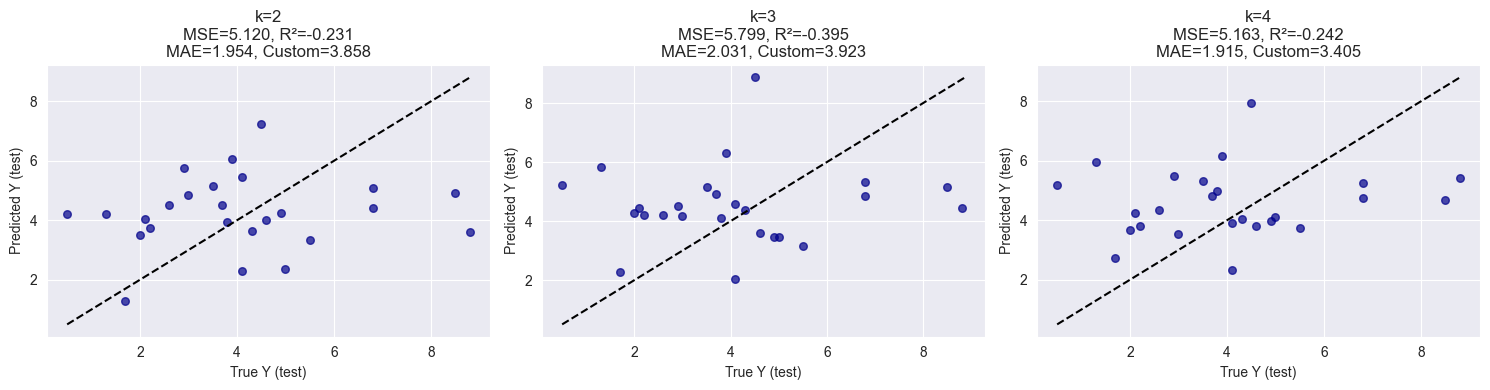

In [62]:
k_values = [2, 3, 4]
c = 0.5
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
test_results = {}

for k in k_values:
    fold_metrics = []

    for train_idx, val_idx in kf.split(X_train_cv):
        X_tr = X_train_cv.iloc[train_idx]
        X_val = X_train_cv.iloc[val_idx]

        y_tr = y_train_cv[train_idx]
        y_val = y_train_cv[val_idx]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsRegressor(n_neighbors=k))
        ])

        model.fit(X_tr, y_tr)
        y_pred_val = model.predict(X_val)

        mse = mean_squared_error(y_val, y_pred_val)
        r2 = r2_score(y_val, y_pred_val)
        mae = mean_absolute_error(y_val, y_pred_val)
        custom = error_metric(y_val, y_pred_val, c)

        fold_metrics.append((mse, r2, mae, custom))

    fold_metrics = np.array(fold_metrics)
    cv_results[k] = fold_metrics

    print(f"\n=== KNN k={k} (5-fold CV) ===")
    print(f"MSE:    {fold_metrics[:, 0].mean():.4f} ± {fold_metrics[:, 0].std():.4f}")
    print(f"R²:     {fold_metrics[:, 1].mean():.4f} ± {fold_metrics[:, 1].std():.4f}")
    print(f"MAE:    {fold_metrics[:, 2].mean():.4f} ± {fold_metrics[:, 2].std():.4f}")
    print(f"Custom: {fold_metrics[:, 3].mean():.4f} ± {fold_metrics[:, 3].std():.4f}")

for k in k_values:
    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])

    final_model.fit(X_train_cv, y_train_cv)
    y_pred_test = final_model.predict(X_test_cv)

    mse_t = mean_squared_error(y_test_cv, y_pred_test)
    r2_t = r2_score(y_test_cv, y_pred_test)
    mae_t = mean_absolute_error(y_test_cv, y_pred_test)
    cust_t = error_metric(y_test_cv, y_pred_test, c)

    test_results[k] = (mse_t, r2_t, mae_t, cust_t)

    print(f"\n=== Final Test Metrics (k={k}) ===")
    print(f"MSE:    {mse_t:.4f}")
    print(f"R²:     {r2_t:.4f}")
    print(f"MAE:    {mae_t:.4f}")
    print(f"Custom: {cust_t:.4f}")

fig, axes = plt.subplots(1, len(k_values), figsize=(5 * len(k_values), 4))

for i, k in enumerate(k_values):
    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])

    final_model.fit(X_train_cv, y_train_cv)
    y_pred_test = final_model.predict(X_test_cv)

    mse_t, r2_t, mae_t, cust_t = test_results[k]

    ax = axes[i]
    ax.scatter(y_test_cv, y_pred_test, alpha=0.7, s=30, color="darkblue")

    mn = min(y_test_cv.min(), y_pred_test.min())
    mx = max(y_test_cv.max(), y_pred_test.max())
    ax.plot([mn, mx], [mn, mx], linestyle="--", color="black")

    ax.set_title(f"k={k}\nMSE={mse_t:.3f}, R²={r2_t:.3f}\nMAE={mae_t:.3f}, Custom={cust_t:.3f}")
    ax.set_xlabel("True Y (test)")
    ax.set_ylabel("Predicted Y (test)")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Task 2.2 Evaluation

## Task 3 Handling missing data

In this task, we add data points where features have missing values. We still use supervised learning (regression), but now leverage more training data through imputation.

**Key Objective**: 
- Experiment with different imputation techniques to recover missing feature values
- Compare model performance with and without imputation
- Apply the best imputation strategy to nonlinear models from Task 2
- Analyze impact on model generalization and data efficiency

### Task 3.1 Missing data imputation

<Axes: >

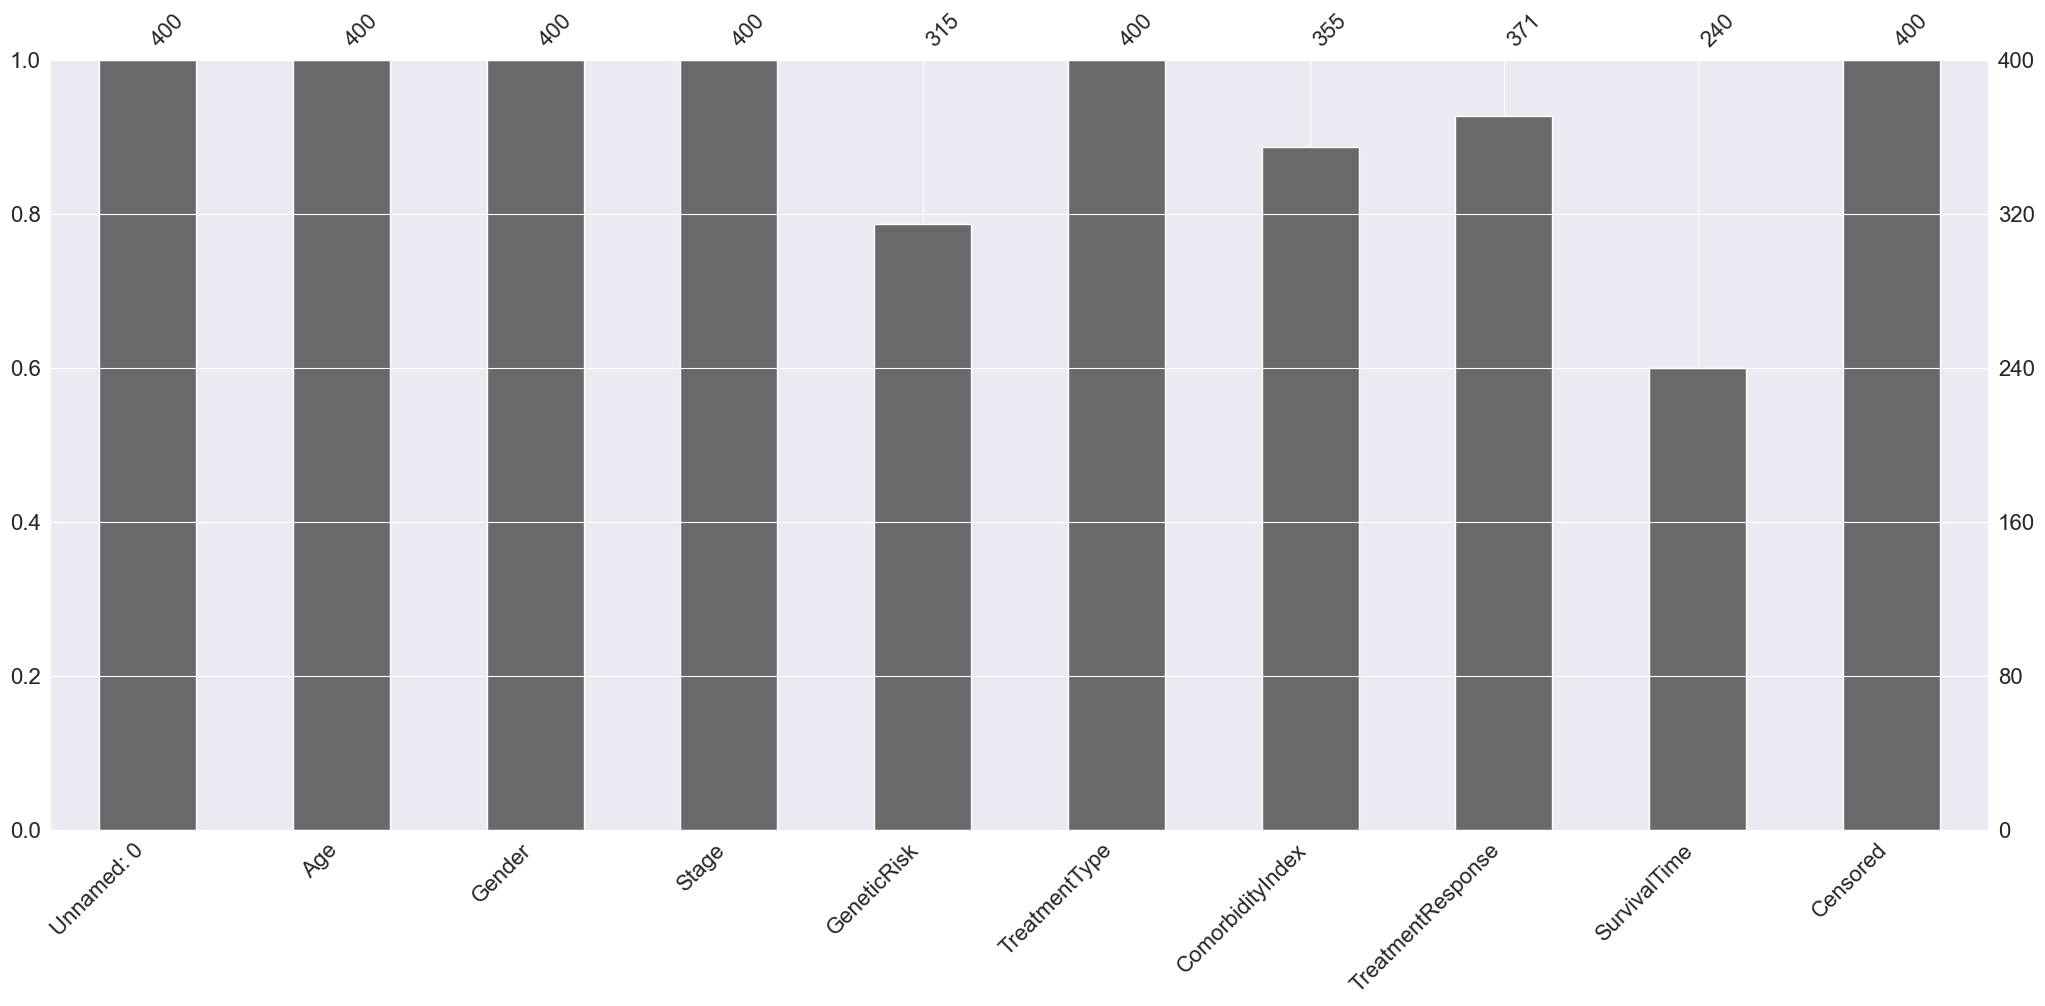

In [63]:
msno.bar(train_csv)

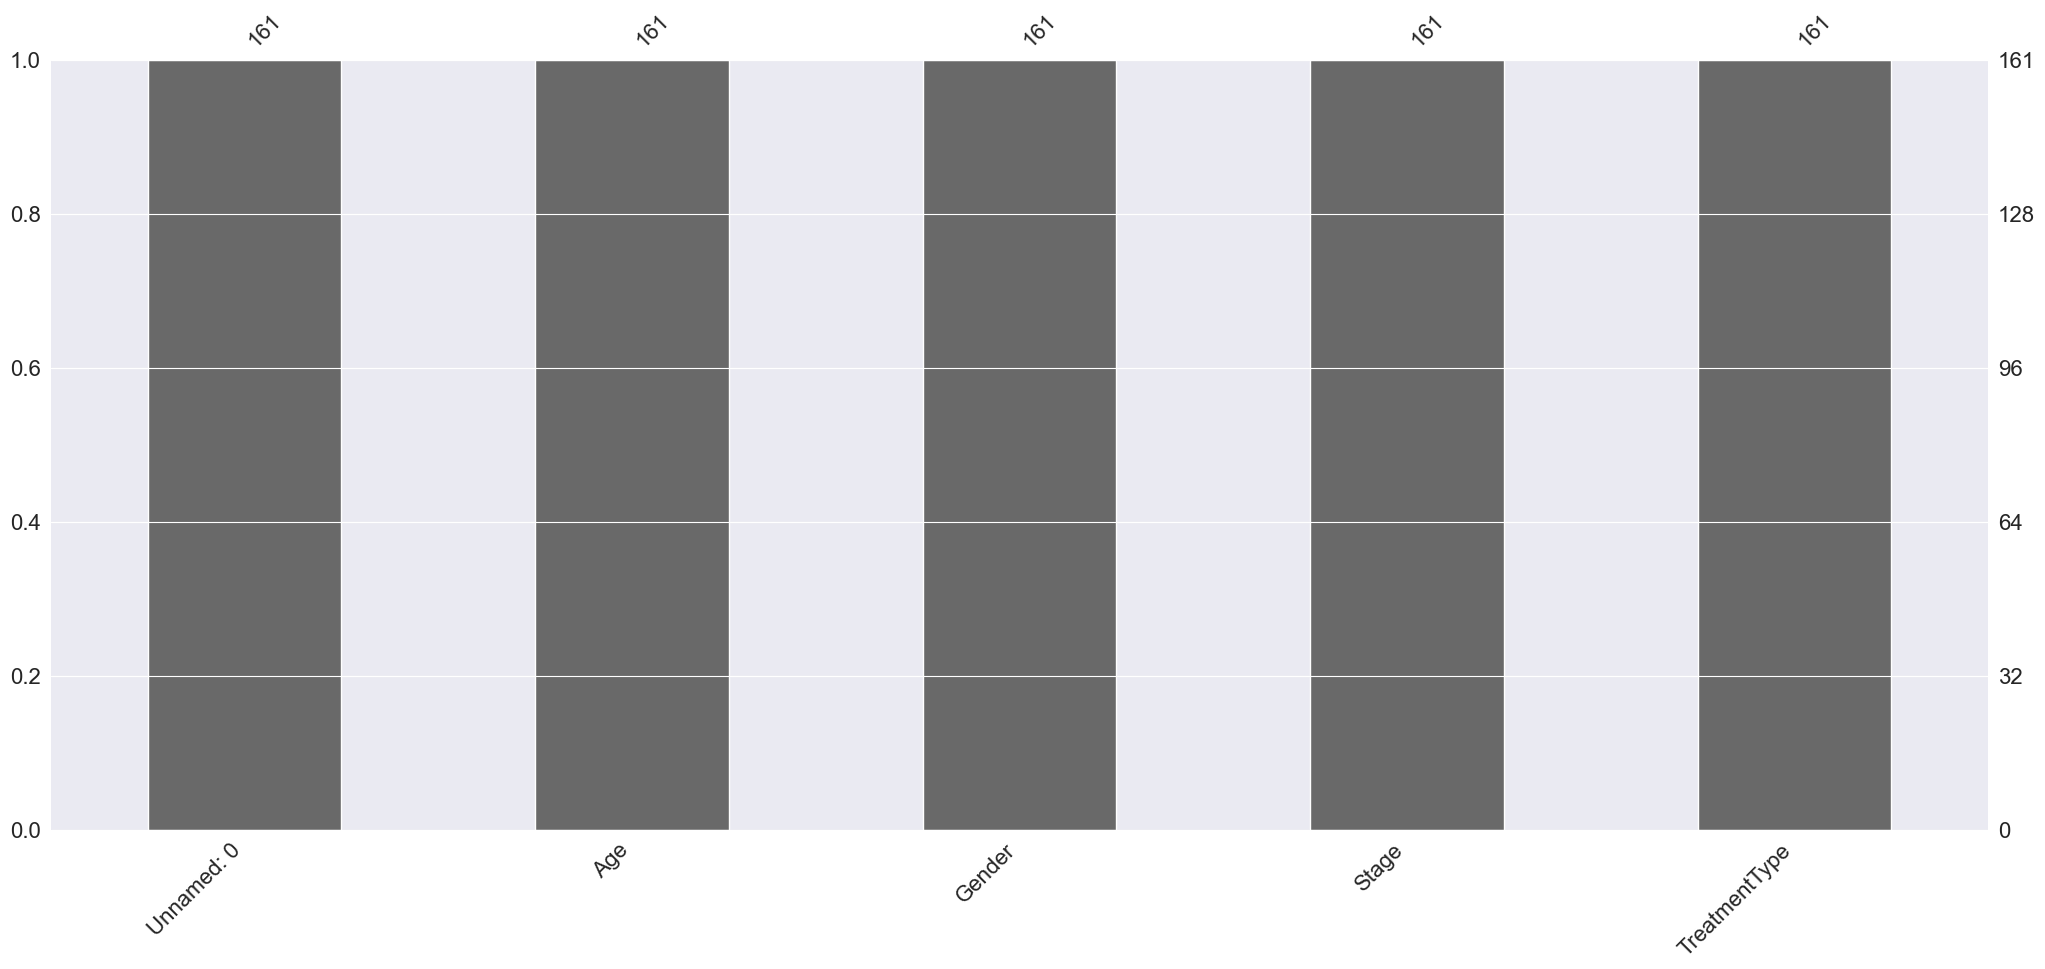


=== Testing imputation: mean ===
cMSE = 2.6230

=== Testing imputation: median ===
cMSE = 2.6230

=== Testing imputation: most_frequent ===
cMSE = 2.6230

=== Testing imputation: knn ===
cMSE = 2.6230

Best imputation strategy: mean


In [64]:
import missingno as msno
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

plt.figure(figsize=(8, 4))
msno.bar(pd.DataFrame(X, columns=feature_names))
plt.show()

imputers = {
    "mean": SimpleImputer(strategy="mean"),
    "median": SimpleImputer(strategy="median"),
    "most_frequent": SimpleImputer(strategy="most_frequent"),
    "knn": KNNImputer(n_neighbors=5)
}

results_31 = {}

for name, imputer in imputers.items():
    print(f"\n=== Testing imputation: {name} ===")
    pipe = Pipeline([
        ("imputer", imputer),
        ("scaler", StandardScaler()),
        ("linreg", LinearRegression())
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    err = error_metric(y_test, pred, c_test)
    results_31[name] = err
    print(f"cMSE = {err:.4f}")

best_method = min(results_31, key=results_31.get)
print("\nBest imputation strategy:", best_method)


### Task 3.2 Apply best imputation to nonlinear models

In [65]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

print("\n=== Task 3.2: Nonlinear Models (Missing-aware or Made Missing-aware) ===")

models_32 = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=300),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42)
}

results_32 = {}

for name, model in models_32.items():
    print(f"\nTraining {name}...")
    if name != "HistGradientBoosting":
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", model)
        ])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    err = error_metric(y_test, pred, c_test)
    results_32[name] = err
    print(f"{name} cMSE = {err:.4f}")

best_nonlin = min(results_32, key=results_32.get)
print("\nBest nonlinear model:", best_nonlin)
print("Best nonlinear model cMSE:", results_32[best_nonlin])



=== Task 3.2: Nonlinear Models (Missing-aware or Made Missing-aware) ===

Training Decision Tree...
Decision Tree cMSE = 7.8388

Training Random Forest...
Random Forest cMSE = 3.3854

Training Gradient Boosting...
Gradient Boosting cMSE = 2.7044

Training HistGradientBoosting...
HistGradientBoosting cMSE = 3.4670

Best nonlinear model: Gradient Boosting
Best nonlinear model cMSE: 2.7043662676236937


### Task 3.3 Evaluation

In [66]:
kaggle_test = pd.read_csv("test_data.csv")

cols_to_drop = [4, 6, 7]
kaggle_test2 = kaggle_test.drop(kaggle_test.columns[cols_to_drop], axis=1)

X_kaggle = kaggle_test2.drop(columns=["id"], errors="ignore")
X_kaggle = X_kaggle.drop(columns=["SurvivalTime", "Censored"], errors="ignore")
X_kaggle = X_kaggle.to_numpy()

print("Train features:", X_train.shape[1])
print("Kaggle features:", X_kaggle.shape[1])

print("\n=== Task 3.3 Evaluation ===")

df_31 = pd.DataFrame.from_dict(results_31, orient="index", columns=["cMSE"])
df_32 = pd.DataFrame.from_dict(results_32, orient="index", columns=["cMSE"])

df_31["Model Type"] = "Imputation + Linear Regression"
df_32["Model Type"] = "Missing-aware Nonlinear Model"

evaluation_table = pd.concat([df_31, df_32])
display(evaluation_table.style.format({"cMSE": "{:.4f}"}))

best_overall = evaluation_table["cMSE"].idxmin()
best_value = evaluation_table.loc[best_overall, "cMSE"]

print("\nBest model overall:", best_overall)
print(f"Best model cMSE: {best_value:.4f}")

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

print("\n=== Creating Kaggle Submission File for Task 3 ===")

best_model_name = best_overall

if best_model_name in results_32:
    base_model = models_32[best_model_name]
    if best_model_name == "HistGradientBoosting":
        model = base_model
        model.fit(X_train, y_train)
    else:
        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", base_model)
        ])
        model.fit(X_train, y_train)
else:
    imputer = imputers[best_model_name]
    model = Pipeline([
        ("imputer", imputer),
        ("scaler", StandardScaler()),
        ("linreg", LinearRegression())
    ])
    model.fit(X_train, y_train)

pred_test = model.predict(X_kaggle)

submission = pd.DataFrame({
    "SurvivalTime": pred_test
})

submission.to_csv("handle-missing-submission-01.csv", index=False)

print("Submission file created: handle-missing-submission-01.csv")
submission.head()


Train features: 5
Kaggle features: 4

=== Task 3.3 Evaluation ===


,cMSE,Model Type
mean,2.6230,Imputation + Linear Regression
median,2.6230,Imputation + Linear Regression
most_frequent,2.6230,Imputation + Linear Regression
knn,2.6230,Imputation + Linear Regression
Decision Tree,7.8388,Missing-aware Nonlinear Model
Random Forest,3.3854,Missing-aware Nonlinear Model
Gradient Boosting,2.7044,Missing-aware Nonlinear Model
HistGradientBoosting,3.4670,Missing-aware Nonlinear Model



Best model overall: mean
Best model cMSE: 2.6230

=== Creating Kaggle Submission File for Task 3 ===


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


ValueError: X has 4 features, but SimpleImputer is expecting 5 features as input.

## Task 4 Semi-supervised learning for unlabeled data

### Task 4.1 Imputation with labeled and unlabeled data

In [67]:
from sklearn.manifold import Isomap

print("\n=== Task 4.1 Semi-supervised Isomap ===")

X_all = np.vstack([X_train, X_test])

isomap = Isomap(n_neighbors=10, n_components=10)
X_all_iso = isomap.fit_transform(X_all)

X_train_iso = X_all_iso[:len(X_train)]
X_test_iso = X_all_iso[len(X_train):]

print("Isomap embedding shapes:")
print("Train:", X_train_iso.shape)
print("Test:", X_test_iso.shape)


=== Task 4.1 Semi-supervised Isomap ===
Isomap embedding shapes:
Train: (112, 10)
Test: (25, 10)


### Task 4.2 Evaluation

In [68]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

print("\n=== Task 4.2 Evaluating models on Isomap embeddings ===")

models_41 = {
    "RF_Isomap": RandomForestRegressor(n_estimators=400, random_state=42),
    "HGB_Isomap": HistGradientBoostingRegressor(random_state=42)
}

results_41 = {}

for name, model in models_41.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_iso, y_train)
    pred = model.predict(X_test_iso)
    err = error_metric(y_test, pred, c=0.5)
    results_41[name] = err
    print(f"{name} cMSE = {err:.4f}")

best_41 = min(results_41, key=results_41.get)
best_41_value = results_41[best_41]

print("\nBest Isomap-based model:", best_41)
print(f"cMSE: {best_41_value:.4f}")


=== Task 4.2 Evaluating models on Isomap embeddings ===

Training RF_Isomap...
RF_Isomap cMSE = 2.2300

Training HGB_Isomap...
HGB_Isomap cMSE = 2.9875

Best Isomap-based model: RF_Isomap
cMSE: 2.2300


In [69]:
print("\n=== Creating Kaggle submission for Task 4 ===")

kaggle_test = pd.read_csv("test_data.csv")

cols_to_drop = [4, 6, 7]
kaggle_test2 = kaggle_test.drop(kaggle_test.columns[cols_to_drop], axis=1)

X_kaggle_raw = kaggle_test2.drop(
    columns=["Unnamed: 0", "SurvivalTime", "Censored"],
    errors="ignore"
).to_numpy()

X_kaggle_iso = isomap.transform(X_kaggle_raw)

best_model_41 = models_41[best_41]

pred_test_iso = best_model_41.predict(X_kaggle_iso)

submission_4 = pd.DataFrame({
    "SurvivalTime": pred_test_iso
})

filename_4 = "semisupervised-submission-01.csv"
submission_4.to_csv(filename_4, index=False)

print(f"Submission file created: {filename_4}")
submission_4.head()


=== Creating Kaggle submission for Task 4 ===
Submission file created: semisupervised-submission-01.csv


,SurvivalTime
0,6.23050
1,5.07175
2,5.42275
3,5.14525
4,4.81850


## Task 5 [optional]